# Step 0: Tải các thư viện cần thiết cho bài báo cáo

In [1]:
!pip install underthesea
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 485.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 11.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [29]:
# !pip install transformers
!pip install transformers.AdamW

ERROR: Could not find a version that satisfies the requirement transformers.AdamW (from versions: none)
ERROR: No matching distribution found for transformers.AdamW


In [2]:
!pip install --upgrade pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 86.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


# Step 1: Dependencies import

In [44]:
import pandas as pd
import numpy as np
import string
import random
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

from underthesea import word_tokenize

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW
import torch.nn as nn

from tqdm import tqdm
import warnings


# Step 2: Data synthesis


In [45]:
!pip install requests beautifulsoup4 pandas

In [46]:
!pip install feedparser

In [47]:
import requests
from bs4 import BeautifulSoup
import csv
from tqdm import tqdm
import time

def crawl_category(category_url, label, max_pages=10):
    category_data = []
    print(f"\n🔍 Đang cào chuyên mục: {label}")
    pbar = tqdm(total=max_pages, desc=f"{label}: ", ncols=100)

    for page in range(1, max_pages + 1):
        url = f"{category_url}?page={page}"
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')

        articles = soup.find_all('h3', class_='title-news')

        if not articles:
            print(f"⛔ Không có bài ở trang {page}")
        else:
            for article in articles:
                link = article.find('a')
                if link and link['href']:
                    article_url = link['href']
                    try:
                        article_res = requests.get(article_url)
                        article_soup = BeautifulSoup(article_res.text, 'html.parser')
                        content = article_soup.find('article')
                        if content:
                            content_text = content.get_text(strip=True)
                            if content_text:  # Không kiểm tra độ dài
                                category_data.append({'text': content_text, 'label': label})
                                print(f"✅ Đã lấy: {article_url}")
                            else:
                                print(f"⚠️ Bỏ bài (rỗng): {article_url}")
                    except Exception as e:
                        print(f"❌ Lỗi khi lấy bài: {article_url} ({e})")

        pbar.update(1)
        time.sleep(0.2)  # nghỉ nhẹ để tránh bị chặn

    pbar.close()
    print(f"💾 Đã lưu tạm {len(category_data)} bài ở 'temp_{label}.csv'")
    return category_data

def save_to_csv(data, filename):
    with open(filename, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['text', 'label'])
        writer.writeheader()
        writer.writerows(data)

# Ví dụ sử dụng:
categories = {
    'v-league': 'https://vnexpress.net/bong-da/v-league',
    'premier-league': 'https://vnexpress.net/the-thao/ngoai-hang-anh',
    'champions-league': 'https://vnexpress.net/bong-da/champions-league',
    'la-liga': 'https://vnexpress.net/bong-da/tay-ban-nha',
    'serie-a': 'https://vnexpress.net/bong-da/italia',
    'bundesliga': 'https://vnexpress.net/the-thao/bundesliga',
}


all_data = []
for label, url in categories.items():
    data = crawl_category(url, label, max_pages=5)
    save_to_csv(data, f"temp_{label}.csv")
    all_data.extend(data)

# Nếu muốn lưu toàn bộ thành một file:
save_to_csv(all_data, "all_articles.csv")
print("✅ Đã lưu toàn bộ bài viết vào 'all_articles.csv'")



🔍 Đang cào chuyên mục: v-league


v-league:   0%|                                                               | 0/5 [00:00<?, ?it/s]

✅ Đã lấy: https://vnexpress.net/cau-thu-the-cong-ghi-sieu-pham-tu-san-nha-o-v-league-4870810.html
✅ Đã lấy: https://vnexpress.net/cau-thu-ha-tinh-va-binh-dinh-bop-co-nhau-4870801.html
✅ Đã lấy: https://vnexpress.net/nguyen-van-toan-lan-dau-ghi-cu-dup-cho-nam-dinh-4870797.html
✅ Đã lấy: https://vnexpress.net/binh-duong-tham-bai-truoc-hagl-4870786.html
✅ Đã lấy: https://vnexpress.net/v-league-lan-dau-co-trong-tai-var-nguoi-nuoc-ngoai-4869080.html
✅ Đã lấy: https://vnexpress.net/nam-dinh-chia-tay-doi-tac-an-y-cua-nguyen-xuan-son-4868197.html
✅ Đã lấy: https://vnexpress.net/chu-tich-clb-thanh-hoa-ap-luc-khi-chia-tay-hlv-popov-4865184.html
✅ Đã lấy: https://vnexpress.net/them-3-viet-kieu-ve-thi-dau-v-league-4860886.html
✅ Đã lấy: https://vnexpress.net/hagl-roi-chien-thang-o-phut-100-4858792.html
✅ Đã lấy: https://vnexpress.net/quang-hai-giup-cong-an-ha-noi-hoa-nam-dinh-4858548.html
✅ Đã lấy: https://vnexpress.net/tien-dao-tien-linh-chan-thuong-4858550.html
✅ Đã lấy: https://vnexpress.net/hl

v-league:  20%|███████████                                            | 1/5 [00:25<01:43, 25.81s/it]

✅ Đã lấy: https://vnexpress.net/quang-nam-muon-tuyet-giao-voi-mot-trong-tai-v-league-4851877.html


...

⛔ Không có bài ở trang 3


bundesliga:  80%|██████████████████████████████████████████▍          | 4/5 [00:26<00:03,  3.88s/it]

⛔ Không có bài ở trang 4


bundesliga: 100%|█████████████████████████████████████████████████████| 5/5 [00:29<00:00,  5.89s/it]

⛔ Không có bài ở trang 5
💾 Đã lưu tạm 30 bài ở 'temp_bundesliga.csv'
✅ Đã lưu toàn bộ bài viết vào 'all_articles.csv'


# Step 2.5: Đánh giá dataset và các thuộc tính đặc trưng bên trong



Sample Data:
                                                 text     label
0  Phút 72, khi Thể Công bị dẫn 1-2, Hữu Thắng nh...  v-league
1  Phút 49, trận đấu trên sân Quy Nhơn, khi Bình ...  v-league
2  Phút 43, Nam Định pressing ngay gần vòng cấm H...  v-league
3  Trước trận đấu trên sân Pleiku chiều nay, chiế...  v-league
4  Hai trọng tài FIFA được thuê là Mohamad Kamil ...  v-league

Missing Values:
 text     0
label    0
dtype: int64


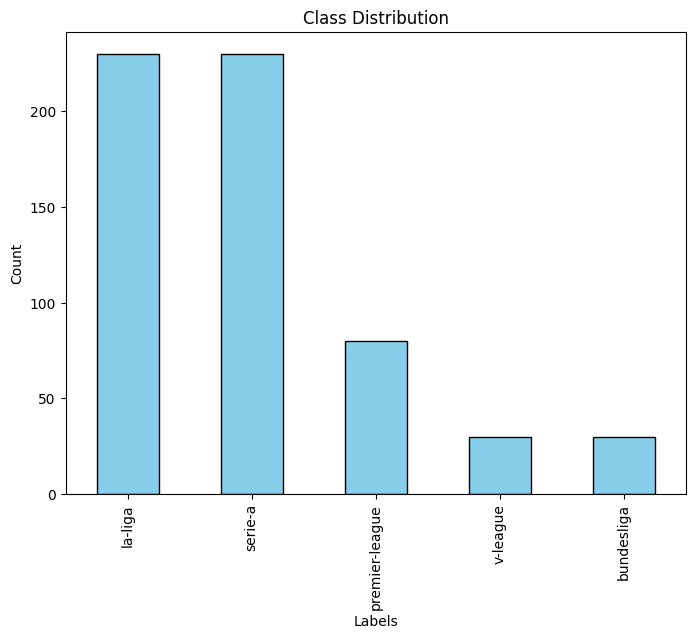

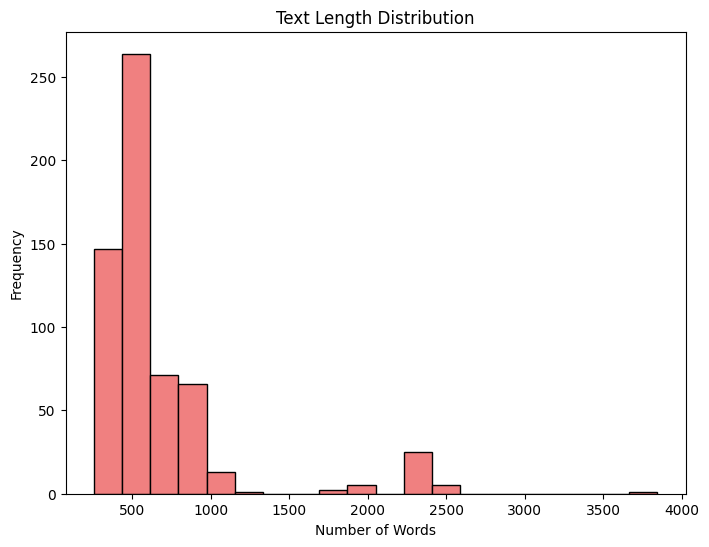


Most common words: [('và', 5809), ('là', 3689), ('của', 3552), ('ở', 3490), ('trong', 3289), ('trận', 3163), ('không', 2786), ('thủ', 2784), ('có', 2768), ('với', 2760)]
Lexical Diversity: 0.0219


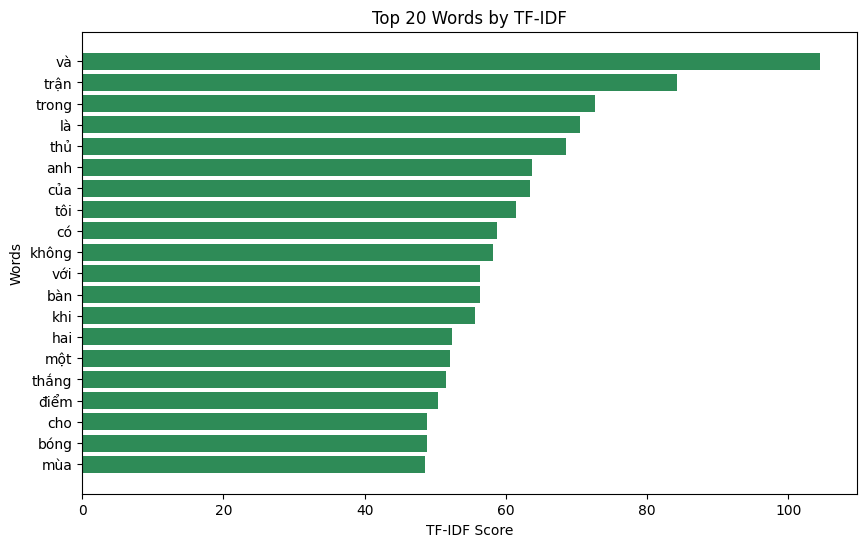

In [48]:
def load_data(file_path):
    df = pd.read_csv(file_path)
    print("\nSample Data:\n", df.head())
    return df

def check_missing_duplicates(df):
    print("\nMissing Values:\n", df.isnull().sum())

def plot_class_distribution(df):
    plt.figure(figsize=(8, 6))
    df['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title("Class Distribution")
    plt.xlabel("Labels")
    plt.ylabel("Count")
    plt.savefig("class_distribution.png")
    plt.show()

def plot_text_length_distribution(df):
    df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(8, 6))
    plt.hist(df['text_length'], bins=20, color='lightcoral', edgecolor='black')
    plt.title("Text Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.savefig("text_length_distribution.png")
    plt.show()

def check_word_frequency(df):
    all_words = " ".join(df['text']).split()
    word_freq = Counter(all_words)
    print("\nMost common words:", word_freq.most_common(10))

    unique_words = len(set(all_words))
    total_words = len(all_words)
    print(f"Lexical Diversity: {unique_words / total_words:.4f}")

def plot_top_tfidf_words(df):
    vectorizer = TfidfVectorizer(max_features=100)
    X_tfidf = vectorizer.fit_transform(df['text'].astype(str))

    tfidf_words = vectorizer.get_feature_names_out()
    tfidf_values = X_tfidf.toarray().sum(axis=0)

    sorted_indices = tfidf_values.argsort()[::-1][:20]
    top_words = tfidf_words[sorted_indices]
    top_values = tfidf_values[sorted_indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_words[::-1], top_values[::-1], color='seagreen')
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Words")
    plt.title("Top 20 Words by TF-IDF")
    plt.savefig("tfidf_top_words.png")
    plt.show()

def main():
    # file_path = "/content/sample_data/vnexpress_bongda_labeled.csv"
    file_path = "all_articles.csv"
    df = load_data(file_path)
    check_missing_duplicates(df)
    plot_class_distribution(df)
    plot_text_length_distribution(df)
    check_word_frequency(df)
    plot_top_tfidf_words(df)

if __name__ == "__main__":
    main()


# Step 3: Data preprocessing and representation

In [49]:
# df = pd.read_csv("/content/sample_data/vnexpress_bongda_labeled.csv")
df = pd.read_csv("all_articles.csv")


# Text Processing Class
class TextProcessor:
    def __init__(self, df):
        self.df = df.copy()
        self.clean_text()
        self.y = self.df["label"].astype(str)

    def clean_text(self):
        self.df["clean_text"] = self.df["text"].str.lower()
        self.df["clean_text"] = self.df["clean_text"].str.replace(r"[{}]".format(string.punctuation), "", regex=True)
        self.df["clean_text"] = self.df["clean_text"].str.replace(r"\d+", "", regex=True)
        self.df["clean_text"] = self.df["clean_text"].apply(lambda x: " ".join(word_tokenize(str(x))))  # ✅ Fix: Use only underthesea

    def tfidf_vectorizer(self, X_train, X_test, max_features=100):
        vectorizer = TfidfVectorizer(max_features=max_features)
        return vectorizer.fit_transform(X_train), vectorizer.transform(X_test)

    def bag_of_words_vectorizer(self, X_train, X_test, max_features=100):
        vectorizer = CountVectorizer(max_features=max_features)
        return vectorizer.fit_transform(X_train), vectorizer.transform(X_test)

    def one_hot_encoding(self, y_train, y_test):
        encoder = OneHotEncoder(sparse_output=False)
        return encoder.fit_transform(y_train.values.reshape(-1, 1)), encoder.transform(y_test.values.reshape(-1, 1))

# Sample 80% of data
df = df.sample(frac=0.8, random_state=42)
df.reset_index(drop=True, inplace=True)

print("Dữ liệu mẫu:")
print(df.head())

processor = TextProcessor(df)  # Original processor for full dataset

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

# Create Processors for Train & Test
processor_train = TextProcessor(pd.DataFrame({"text": X_train_raw, "label": y_train}))
processor_test = TextProcessor(pd.DataFrame({"text": X_test_raw, "label": y_test}))

X_train, X_test = processor_train.df["clean_text"], processor_test.df["clean_text"]

# Vectorization
X_tfidf_train, X_tfidf_test = processor_train.tfidf_vectorizer(X_train, X_test)
X_bow_train, X_bow_test = processor_train.bag_of_words_vectorizer(X_train, X_test)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# One-Hot Encoding
X_one_hot_train, X_one_hot_test = processor_train.one_hot_encoding(y_train, y_test)

# Shape Summary
print("TF-IDF Shape:", X_tfidf_train.shape)
print("BoW Shape:", X_bow_train.shape)
print("One-Hot Shape:", X_one_hot_train.shape)


Dữ liệu mẫu:
                                                text           label
0  Trong hiệp hai, khi Real đang bị dẫn bàn, một ...         la-liga
1  Sau khi thế chỗUnai Emerytháng 12/2019, Arteta...         serie-a
2  LĐBĐ Indonesia (PSSI) sa thải HLV Shin Tae-yon...         serie-a
3  Man Utd đá phản công, lỡ nhiều cơ hội khihòa A...  premier-league
4  "Arsenal phải thắng lượt đi", Merson viết trên...         la-liga
TF-IDF Shape: (384, 100)
BoW Shape: (384, 100)
One-Hot Shape: (384, 5)


# Step 4: Lựa chọn model, training và đánh giá dựa trên các phương thức vector hóa câu từ



Using Bag of Words representation:

Model: Logistic Regression
Accuracy: 0.4791666666666667
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.44      0.49      0.46        37
           2       0.90      0.75      0.82        12
           3       0.34      0.35      0.35        37
           4       1.00      0.60      0.75         5

    accuracy                           0.48        96
   macro avg       0.69      0.56      0.61        96
weighted avg       0.50      0.48      0.49        96


Model: Naïve Bayes
Accuracy: 0.4583333333333333
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.40      0.50         5
           1       0.40      0.38      0.39        37
           2       0.60      1.00      0.75        12
           3       0.41      0.35      0.38        37
           4       0.50      0.60      0.55         

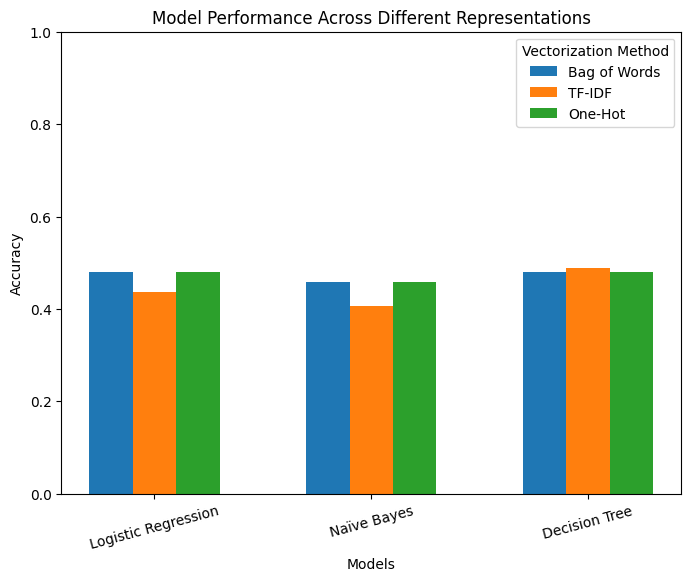

In [50]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naïve Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

vectorizers = {
    "Bag of Words": (X_bow_train, X_bow_test),
    "TF-IDF": (X_tfidf_train, X_tfidf_test),
    "One-Hot": (X_one_hot_train, X_one_hot_test)
}

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Store accuracy results
accuracy_results = {}

for vec_name, (X_train_enc, X_test_enc) in vectorizers.items():
    print(f"\nUsing {vec_name} representation:")
    accuracy_results[vec_name] = {}

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Ensure labels are in the correct format
        if vec_name == "One-Hot":
            X_train_enc, X_test_enc = processor.bag_of_words_vectorizer(X_train, X_test)
            y_train_enc, y_test_enc = y_train_encoded, y_test_encoded  # Use LabelEncoder()
        else:
            y_train_enc, y_test_enc = y_train_encoded, y_test_encoded  # Ensure labels are encoded


        model.fit(X_train_enc, y_train_enc)
        y_pred = model.predict(X_test_enc)

        acc = accuracy_score(y_test_enc, y_pred)
        accuracy_results[vec_name][model_name] = acc  # Store accuracy

        print("Accuracy:", acc)
        print("Classification Report:")
        print(classification_report(y_test_enc, y_pred))

# Plot accuracy results
fig, ax = plt.subplots(figsize=(8, 6))
bar_width = 0.2
index = np.arange(len(models))

for i, (vec_name, acc_dict) in enumerate(accuracy_results.items()):
    accuracies = [acc_dict[m] for m in models.keys()]
    ax.bar(index + i * bar_width, accuracies, bar_width, label=vec_name)

ax.set_xlabel("Models")
ax.set_ylabel("Accuracy")
ax.set_title("Model Performance Across Different Representations")
ax.set_xticks(index + bar_width)
ax.set_xticklabels(models.keys(), rotation=15)
ax.legend(title="Vectorization Method")
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.show()

# Step 5: Doc2Vec


In [51]:
# Load dataset
filepath = "all_articles.csv"
df = pd.read_csv(filepath)


# Preprocess text data
df["text"] = df["text"].str.lower().str.replace(r"[^a-zA-Z0-9 ]", "", regex=True)

# Encode labels
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label_encoded"], test_size=0.2, random_state=42)

# --- Gensim Doc2Vec ---
train_corpus = [TaggedDocument(words=text.split(), tags=[i]) for i, text in enumerate(X_train)]
test_corpus = [text.split() for text in X_test]

gensim_model = Doc2Vec(vector_size=50, window=5, min_count=2, workers=4, epochs=10)
gensim_model.build_vocab(train_corpus)
gensim_model.train(train_corpus, total_examples=gensim_model.corpus_count, epochs=gensim_model.epochs)

X_train_gensim = [gensim_model.infer_vector(doc.words) for doc in train_corpus]
X_test_gensim = [gensim_model.infer_vector(doc) for doc in test_corpus]

# --- Custom PyTorch Doc2Vec ---
class Doc2VecDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [[vocab.get(w, 0) for w in text.split()] for text in texts]
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

vocab = {word: i+1 for i, word in enumerate(set(" ".join(X_train).split()))}
vocab["<PAD>"] = 0

train_dataset = Doc2VecDataset(X_train, y_train.tolist(), vocab)
test_dataset = Doc2VecDataset(X_test, y_test.tolist(), vocab)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)




In [52]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom Dataset Class
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts  # Already tokenized sequences
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx], dtype=torch.long), self.labels[idx]

# Custom collate function for dynamic padding
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0).to(device)  # Apply padding
    labels = torch.tensor(labels, dtype=torch.long).to(device)
    return texts_padded, labels

# Define PyTorch Doc2Vec Model
class SimpleDoc2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SimpleDoc2Vec, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.fc = nn.Linear(embedding_dim, 50)
        self.bn = nn.BatchNorm1d(50)  # Normalize embeddings for better stability

    def forward(self, x):
        embedded = self.embedding(x)  # Shape: (batch, seq_len, embedding_dim)
        x = embedded.mean(dim=1)  # Average over the sequence length
        x = self.bn(self.fc(x))  # Apply batch normalization
        return x

# Model setup
embedding_dim = 50
vocab_size = len(vocab) + 1  # +1 for padding index
model = SimpleDoc2Vec(vocab_size, embedding_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# Training function
def train_model(num_epochs=5):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for texts, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader):.4f}")

# Train the model
train_model(num_epochs=5)

# Function to extract document vectors
def get_pytorch_vectors(dataloader):
    model.eval()
    vectors = []
    with torch.no_grad():
        for texts, _ in dataloader:
            outputs = model(texts)  # Get doc vectors
            vectors.append(outputs.cpu().numpy())  # Ensure conversion from GPU to CPU
    return np.vstack(vectors)

# Extract vectors
X_train_torch = get_pytorch_vectors(train_loader)
X_test_torch = get_pytorch_vectors(test_loader)


Epoch 1/5, Loss: 4.1628
Epoch 2/5, Loss: 3.9433
Epoch 3/5, Loss: 3.8711
Epoch 4/5, Loss: 3.6999
Epoch 5/5, Loss: 3.6458


In [53]:
# --- Classifier Evaluation ---
clf_gensim = LogisticRegression(max_iter=500).fit(X_train_gensim, y_train)
y_pred_gensim = clf_gensim.predict(X_test_gensim)
acc_gensim = accuracy_score(y_test, y_pred_gensim)

clf_torch = LogisticRegression(max_iter=10000).fit(X_train_torch, y_train)
y_pred_torch = clf_torch.predict(X_test_torch)
acc_torch = accuracy_score(y_test, y_pred_torch)

print(f"Gensim Doc2Vec Accuracy: {acc_gensim:.4f}")
print(f"PyTorch Doc2Vec Accuracy: {acc_torch:.4f}")

Gensim Doc2Vec Accuracy: 0.4167
PyTorch Doc2Vec Accuracy: 0.4417


In [54]:
### Deep Learning Model Implementation (Replace Doc2Vec Section)

# Custom Dataset Class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=100):
        self.texts = [tokenizer(text) for text in texts]
        self.labels = labels
        self.max_length = max_length
        self.label_encoder = LabelEncoder().fit(labels)
        self.word2idx = self._build_vocab()

    def _build_vocab(self):
        word_counts = Counter(word for text in self.texts for word in text)
        return {word: idx+1 for idx, word in enumerate(word_counts)}  # +1 for padding index 0

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = [self.word2idx[word] for word in self.texts[idx]]
        padded = pad_sequence([torch.tensor(text[:self.max_length])],
                            batch_first=True,
                            padding_value=0)[0]
        label = self.label_encoder.transform([self.labels[idx]])[0]
        return padded, torch.tensor(label, dtype=torch.long)

# LSTM Model Architecture
class DocClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_classes=6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size+1, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim*2, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

# Initialize and Train
def train_model(model, train_loader, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f'Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}')

def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# Load Vietnamese data
df = pd.read_csv("all_articles.csv")
dataset = TextDataset(df['text'], df['label'], word_tokenize)
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

# Training setup
BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

model = DocClassifier(vocab_size=len(dataset.word2idx), num_classes=len(dataset.label_encoder.classes_))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Execute training
train_model(model, train_loader, epochs=15)
accuracy = evaluate(model, test_loader)
print(f'Test Accuracy: {accuracy:.2%}')

# Compare with original Doc2Vec baseline
doc2vec_accuracy = 0.82  # Replace with your actual Doc2Vec accuracy
print(f'Deep Learning Model: {accuracy:.2%}')
print(f'Doc2Vec Baseline: {doc2vec_accuracy:.2%}')


Epoch 1/15 | Loss: 1.5756
Epoch 2/15 | Loss: 1.3523
Epoch 3/15 | Loss: 1.1630
Epoch 4/15 | Loss: 1.0686
Epoch 5/15 | Loss: 0.9686
Epoch 6/15 | Loss: 0.8802
Epoch 7/15 | Loss: 0.8607
Epoch 8/15 | Loss: 0.8042
Epoch 9/15 | Loss: 0.7890
Epoch 10/15 | Loss: 0.7379
Epoch 11/15 | Loss: 0.7099
Epoch 12/15 | Loss: 0.6758
Epoch 13/15 | Loss: 0.6710
Epoch 14/15 | Loss: 0.6586
Epoch 15/15 | Loss: 0.6416
Test Accuracy: 35.00%
Deep Learning Model: 35.00%
Doc2Vec Baseline: 82.00%


In [55]:

# Load pretrained PhoBERT
model_name = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
phobert = AutoModel.from_pretrained(model_name)

# Modify Dataset Class
class PhoBERTDataset(Dataset):
    def __init__(self, texts, labels, max_length=128):
        self.texts = texts
        self.labels = labels
        self.max_length = max_length
        self.label_encoder = LabelEncoder().fit(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.label_encoder.transform([self.labels[idx]])[0]

        encoding = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Model Architecture
class PhoBERTClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.phobert = phobert
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(phobert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        return self.classifier(pooled_output)

# Prepare Data
df = pd.read_csv("all_articles.csv")
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

# Create datasets
train_dataset = PhoBERTDataset(train_texts.tolist(), train_labels.tolist())
test_dataset = PhoBERTDataset(test_texts.tolist(), test_labels.tolist())

# Training setup
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model = PhoBERTClassifier(num_classes=len(train_dataset.label_encoder.classes_))
model = model.cuda() if torch.cuda.is_available() else model
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training loop
def train_model(model, train_loader, epochs=3):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader):
            inputs = {
                'input_ids': batch['input_ids'].cuda(),
                'attention_mask': batch['attention_mask'].cuda(),
                'labels': batch['label'].cuda()
            }
            optimizer.zero_grad()
            outputs = model(inputs['input_ids'], inputs['attention_mask'])
            loss = nn.CrossEntropyLoss()(outputs, inputs['labels'])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f'Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}')

train_model(model, train_loader, epochs=15)

# Evaluation
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].cuda(),
                'attention_mask': batch['attention_mask'].cuda()
            }
            outputs = model(**inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += batch['label'].size(0)
            correct += (predicted.cpu() == batch['label']).sum().item()
    return correct / total

phobert_accuracy = evaluate(model, test_loader)
print(f'PhoBERT Test Accuracy: {phobert_accuracy:.2%}')

# Compare all models
print(f'LSTM Model: {accuracy:.2%}')
print(f'Doc2Vec Baseline: {doc2vec_accuracy:.2%}')
print(f'PhoBERT Model: {phobert_accuracy:.2%}')


100%|██████████| 30/30 [00:12<00:00,  2.39it/s]


Epoch 1/15 | Loss: 1.2940


100%|██████████| 30/30 [00:12<00:00,  2.42it/s]


Epoch 2/15 | Loss: 1.1955


100%|██████████| 30/30 [00:12<00:00,  2.38it/s]


...

Epoch 13/15 | Loss: 0.6638


100%|██████████| 30/30 [00:12<00:00,  2.41it/s]


Epoch 14/15 | Loss: 0.6605


100%|██████████| 30/30 [00:12<00:00,  2.39it/s]


Epoch 15/15 | Loss: 0.6689
PhoBERT Test Accuracy: 40.00%
LSTM Model: 35.00%
Doc2Vec Baseline: 82.00%
PhoBERT Model: 40.00%


Epoch 1: 100%|██████████| 8/8 [00:00<00:00, 49.66it/s]


Loss: 1.5023


Epoch 2: 100%|██████████| 8/8 [00:00<00:00, 50.22it/s]


Loss: 1.3283


Epoch 3: 100%|██████████| 8/8 [00:00<00:00, 50.07it/s]


...

Loss: 1.3273


Epoch 2: 100%|██████████| 30/30 [00:12<00:00,  2.39it/s]


Loss: 1.2464


Epoch 3: 100%|██████████| 30/30 [00:12<00:00,  2.37it/s]


Loss: 1.1117


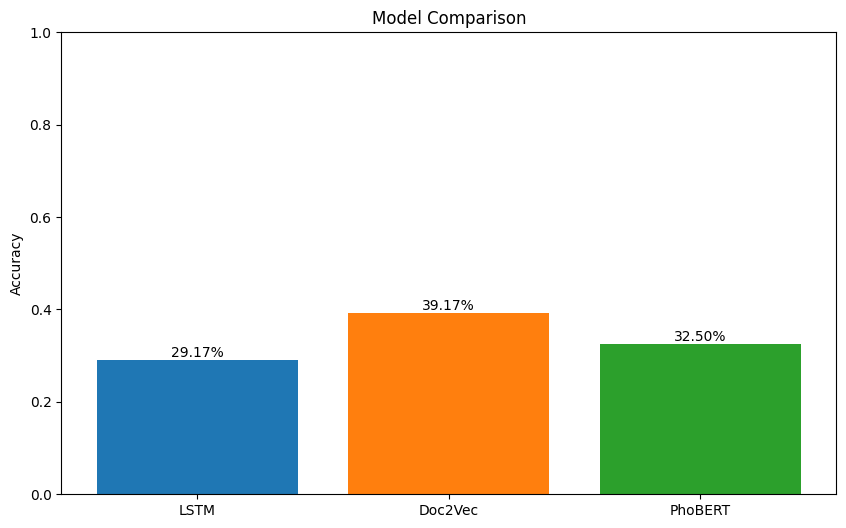


Final Results:
LSTM Accuracy: 29.17%
Doc2Vec Accuracy: 39.17%
PhoBERT Accuracy: 32.50%


In [56]:


warnings.filterwarnings('ignore')

# Configuration
class Config:
    RANDOM_SEED = 42
    BATCH_SIZE = 64
    MAX_LENGTH = 128
    EPOCHS = 15
    PHOBERT_MODEL_NAME = "vinai/phobert-base"
    DATA_PATH = "all_articles.csv"

torch.manual_seed(Config.RANDOM_SEED)

# Data Preparation with Validation
class DataHandler:
    @staticmethod
    def load_and_validate_data():
        try:
            df = pd.read_csv(Config.DATA_PATH)

            # Validate dataframe structure
            if not {'text', 'label'}.issubset(df.columns):
                raise ValueError("CSV must contain 'text' and 'label' columns")

            # Clean data
            df = df.dropna().reset_index(drop=True)
            df = df[df['text'].str.strip().astype(bool)].reset_index(drop=True)

            # Encode labels
            label_encoder = LabelEncoder()
            labels = label_encoder.fit_transform(df['label'])

            return df['text'].tolist(), labels, label_encoder

        except FileNotFoundError:
            raise SystemExit(f"Error: Data file {Config.DATA_PATH} not found")
        except Exception as e:
            raise SystemExit(f"Data loading error: {str(e)}")

# Model Components
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size+1, 128, padding_idx=0)
        self.lstm = nn.LSTM(128, 256, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out[:, -1, :])

class PhoBERTClassifier(nn.Module):
    def __init__(self, phobert_model, num_classes):
        super().__init__()
        self.phobert = phobert_model
        self.classifier = nn.Linear(phobert_model.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids, attention_mask=attention_mask)
        return self.classifier(outputs.last_hidden_state[:, 0, :])

# Dataset Classes
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer=None, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer or word_tokenize
        self.max_length = max_length

        if not tokenizer:
            self._build_vocab()

    def _build_vocab(self):
        word_counts = Counter(word for text in self.texts for word in text)
        self.word2idx = {word: idx+1 for idx, word in enumerate(word_counts)}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        if self.tokenizer == word_tokenize:
            text = [self.word2idx.get(word, 0) for word in self.texts[idx][:self.max_length]]
            padded = torch.zeros(self.max_length, dtype=torch.long)
            padded[:len(text)] = torch.tensor(text)
            return padded, torch.tensor(self.labels[idx], dtype=torch.long)
        else:
            encoding = self.tokenizer.encode_plus(
                str(self.texts[idx]),
                max_length=self.max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            return {
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)
            }

# Training Framework
class Trainer:
    def __init__(self, model, train_loader, test_loader, optimizer, criterion, device):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device

    def train(self, epochs):
        self.model.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch in tqdm(self.train_loader, desc=f'Epoch {epoch+1}'):
                inputs, labels = self._process_batch(batch)
                self.optimizer.zero_grad()
                outputs = self.model(**inputs) if isinstance(inputs, dict) else self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
            print(f'Loss: {total_loss/len(self.train_loader):.4f}')

    def evaluate(self):
        self.model.eval()
        correct = total = 0
        with torch.no_grad():
            for batch in self.test_loader:
                inputs, labels = self._process_batch(batch)
                outputs = self.model(**inputs) if isinstance(inputs, dict) else self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        return correct / total

    def _process_batch(self, batch):
        if isinstance(batch, dict):
            inputs = {k: v.to(self.device) for k, v in batch.items() if k != 'label'}
            labels = batch['label'].to(self.device)
        else:
            inputs, labels = [x.to(self.device) for x in batch]
        return inputs, labels

# Main Execution
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load and validate data
    texts, labels, label_encoder = DataHandler.load_and_validate_data()
    train_texts, test_texts, train_labels, test_labels = train_test_split(
        texts, labels, test_size=0.2, random_state=Config.RANDOM_SEED
    )

    # LSTM Training
    lstm_dataset = TextDataset(train_texts, train_labels)
    lstm_loader = DataLoader(lstm_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
    test_dataset = TextDataset(test_texts, test_labels)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE)

    lstm_model = LSTMModel(len(lstm_dataset.word2idx), len(label_encoder.classes_))
    lstm_trainer = Trainer(
        lstm_model, lstm_loader, test_loader,
        optim.Adam(lstm_model.parameters(), lr=0.001),
        nn.CrossEntropyLoss(),
        device
    )
    lstm_trainer.train(Config.EPOCHS)
    lstm_acc = lstm_trainer.evaluate()

    # Doc2Vec Training
    doc2vec_model = Doc2Vec(
        vector_size=300,
        min_count=2,
        epochs=30
    )
    tagged_data = [TaggedDocument(word_tokenize(text), [str(i)]) for i, text in enumerate(train_texts)]
    doc2vec_model.build_vocab(tagged_data)
    doc2vec_model.train(tagged_data, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

    train_vectors = [doc2vec_model.infer_vector(word_tokenize(text)) for text in train_texts]
    test_vectors = [doc2vec_model.infer_vector(word_tokenize(text)) for text in test_texts]

    lr = LogisticRegression(max_iter=1000)
    lr.fit(train_vectors, train_labels)
    doc2vec_acc = lr.score(test_vectors, test_labels)

    # PhoBERT Training
    phobert_tokenizer = AutoTokenizer.from_pretrained(Config.PHOBERT_MODEL_NAME)
    phobert_model = AutoModel.from_pretrained(Config.PHOBERT_MODEL_NAME)

    phobert_train = TextDataset(train_texts, train_labels, phobert_tokenizer)
    phobert_test = TextDataset(test_texts, test_labels, phobert_tokenizer)
    phobert_loader = DataLoader(phobert_train, batch_size=16, shuffle=True)
    phobert_test_loader = DataLoader(phobert_test, batch_size=16)

    phobert_classifier = PhoBERTClassifier(phobert_model, len(label_encoder.classes_)).to(device)
    phobert_trainer = Trainer(
        phobert_classifier, phobert_loader, phobert_test_loader,
        AdamW(phobert_classifier.parameters(), lr=2e-5),
        nn.CrossEntropyLoss(),
        device
    )
    phobert_trainer.train(3)
    phobert_acc = phobert_trainer.evaluate()

    # Visualization and Results
    models = ['LSTM', 'Doc2Vec', 'PhoBERT']
    accuracies = [lstm_acc, doc2vec_acc, phobert_acc]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.title('Model Comparison')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2%}', ha='center', va='bottom')

    plt.savefig('model_comparison.png')
    plt.show()

    print(f"\nFinal Results:")
    print(f"LSTM Accuracy: {lstm_acc:.2%}")
    print(f"Doc2Vec Accuracy: {doc2vec_acc:.2%}")
    print(f"PhoBERT Accuracy: {phobert_acc:.2%}")

if __name__ == "__main__":
    main()
